In [1]:
!pip install qiskit qiskit-ibm-runtime qiskit-algorithms pylatexenc qiskit-aer
!pip install pandas scikit-learn matplotlib seaborn rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━

 Target Backend: ibm_kingston
Transpiling circuits...
Submitting single batch job to hardware...
Job ID: d79voi1q1efs73d3b5jg (Waiting...)


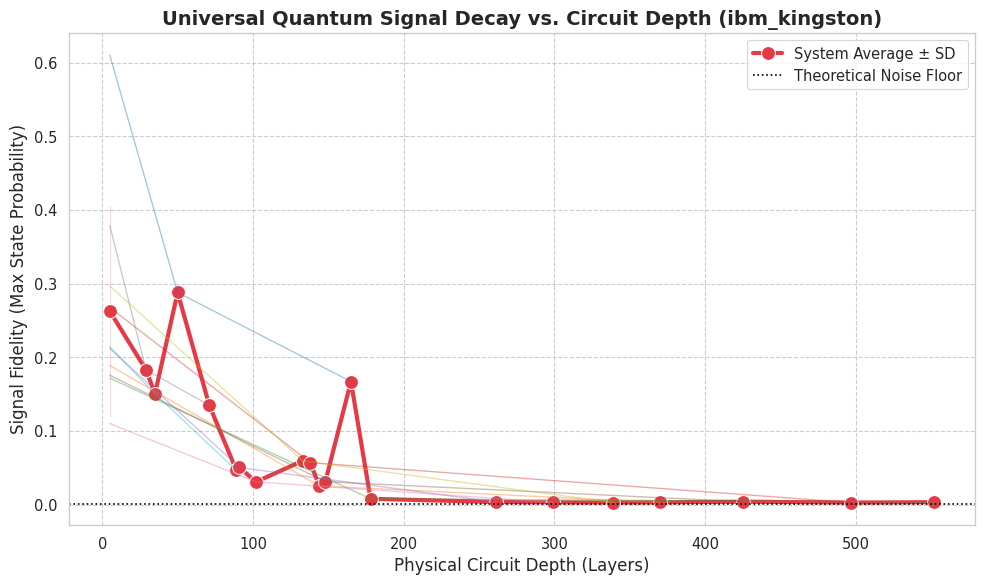

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'C': 2.55, 'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}
N_QUBITS = 12
SHOTS = 4096

# 10 Diverse Molecules
molecules = {
    "Benzene": "C1=CC=C1",
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Nicotine": "CN1CCCC1C2=CN=CC=C2",
    "Dopamine": "C1=CC(=C(C=C1CCN)O)O",
    "Paracetamol": "CC(=O)NC1=CC=C(O)C=C1",
    "Glucose": "C(C1C(C(C(C(O1)O)O)O)O)O",
    "Urea": "C(=O)(N)N",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Glycerol": "C(C(CO)O)O"
}

def build_circuit(smiles, entanglement_layers):
    angle_scale = 0.1
    mol = Chem.MolFromSmiles(smiles)
    qc = QuantumCircuit(N_QUBITS)
    if not mol: return qc

    atoms = list(mol.GetAtoms())
    n_exact = 10
    backbone = atoms[:n_exact]
    tail = atoms[n_exact:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    # 1. ATOMS
    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry((en**2) * angle_scale, mol_to_qubit[atom.GetIdx()])

    if tail:
        tail_A, tail_B = tail[0::2], tail[1::2]
        if tail_A: qc.ry(sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_A) * (angle_scale/2), 10)
        if tail_B: qc.ry(sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_B) * (angle_scale/2), 11)

    # 2. BONDS (Controlled by entanglement_layers)
    for _ in range(entanglement_layers):
        for bond in mol.GetBonds():
            idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            q1, q2 = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
            b_type = bond.GetBondTypeAsDouble()

            if q1 is not None and q2 is not None:
                qc.rxx(b_type * 0.5, q1, q2)
            elif (q1 is not None):
                qc.rxx(0.5, q1, 10); qc.rxx(0.5, q1, 11)
            elif (q2 is not None):
                qc.rxx(0.5, q2, 10); qc.rxx(0.5, q2, 11)

    qc.measure_all()
    return qc

# --- 1. PREPARE ALL 30 CIRCUITS ---
circuits_to_run = []
metadata = []

for mol_name, smiles in molecules.items():
    configs = {
        "Shallow": build_circuit(smiles, 0),
        "Normal (10+2)": build_circuit(smiles, 1),
        "Deep": build_circuit(smiles, 3)
    }
    for config_name, qc in configs.items():
        circuits_to_run.append(qc)
        metadata.append({"Molecule": mol_name, "Configuration": config_name})

# --- 2. HARDWARE EXECUTION ---
token = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(token=token, channel="ibm_cloud", instance=instance, name="Name", overwrite=True)
except: pass

service = QiskitRuntimeService(name="Name")
hw_backend = service.backend("ibm_kingston")
print(f" Target Backend: {hw_backend.name}")
pm = generate_preset_pass_manager(backend=hw_backend, optimization_level=1)

print("Transpiling circuits...")
isa_circuits = pm.run(circuits_to_run)

for i, isa_qc in enumerate(isa_circuits):
    metadata[i]["Transpiled Depth"] = isa_qc.depth()

sampler_hw = RuntimeSampler(mode=hw_backend)
print("Submitting single batch job to hardware...")
job = sampler_hw.run([(c,) for c in isa_circuits], shots=SHOTS)
print(f"Job ID: {job.job_id()} (Waiting...)")
result_hw = job.result()

# --- 3. PROCESS RESULTS ---
results_data = []
for i, pub in enumerate(result_hw):
    counts = pub.data.meas.get_counts()
    max_prob = max(counts.values()) / SHOTS

    row = metadata[i].copy()
    row['Signal Fidelity'] = max_prob
    results_data.append(row)

df_results = pd.DataFrame(results_data)


plt.figure(figsize=(10, 6))
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

# This automatically calculates the mean and standard deviation
sns.lineplot(
    data=df_results, x='Transpiled Depth', y='Signal Fidelity',
    color='#e63946', linewidth=3, marker='o', markersize=10,
    err_style="band", errorbar="sd", label="System Average ± SD"
)

# Plotting the individual molecules lightly in the background
sns.lineplot(
    data=df_results, x='Transpiled Depth', y='Signal Fidelity', hue='Molecule',
    linewidth=1, alpha=0.4, legend=False, palette='tab10'
)

plt.title('Universal Quantum Signal Decay vs. Circuit Depth (ibm_kingston)', fontsize=14, fontweight='bold')
plt.xlabel('Physical Circuit Depth (Layers)', fontsize=12)
plt.ylabel('Signal Fidelity (Max State Probability)', fontsize=12)
plt.axhline(y=1/(2**12), color='black', linestyle=':', label='Theoretical Noise Floor')
plt.legend()
plt.tight_layout()
plt.show()

Connecting to IBM Quantum...
Retrieving Job: d79voi1q1efs73d3b5jg...
Current Job Status: DONE
Job is complete! Downloading results...

--- SUCCESSFULLY RECOVERED DATA ---
  Molecule  Configuration  Signal Fidelity  Depth
0  Benzene        Shallow         0.609863      5
1  Benzene  Normal (10+2)         0.287842    105
2  Benzene           Deep         0.166992    220
3  Aspirin        Shallow         0.188721      5
4  Aspirin  Normal (10+2)         0.025146    105
5  Aspirin           Deep         0.002930    220


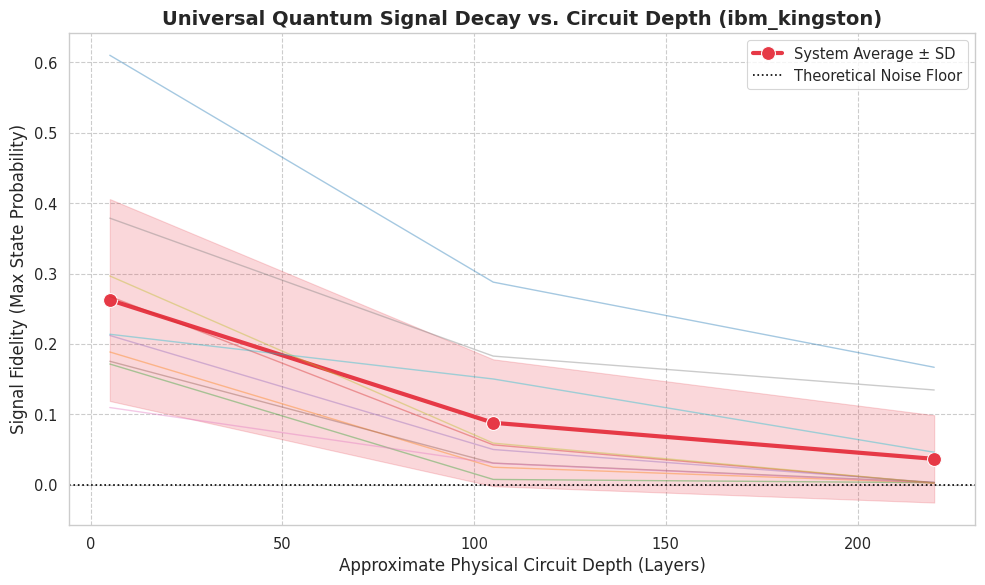

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit_ibm_runtime import QiskitRuntimeService

# --- 1. CONFIGURATION ---
SHOTS = 4096

JOB_ID = "d79voi1q1efs73d3b5jg"

# Recreate the metadata list so we know which circuit was which
molecules = ["Benzene", "Aspirin", "Caffeine", "Nicotine", "Dopamine",
             "Paracetamol", "Glucose", "Urea", "Ibuprofen", "Glycerol"]
configurations = ["Shallow", "Normal (10+2)", "Deep"]

metadata = []
for mol in molecules:
    for config in configurations:
        metadata.append({"Molecule": mol, "Configuration": config})

# --- 2. CONNECT TO IBM AND FETCH JOB ---
print(f"Connecting to IBM Quantum...")
service = QiskitRuntimeService(name="Name")

print(f"Retrieving Job: {JOB_ID}...")
job = service.job(JOB_ID)


status = job.status()
print(f"Current Job Status: {status}")

if str(status) != "JobStatus.DONE" and str(status) != "DONE":
    print("Job is not finished yet. Try again later!")
else:
    print("Job is complete! Downloading results...")
    result_hw = job.result()

    # --- 3. PROCESS THE RESULTS ---
    results_data = []

    for i, pub in enumerate(result_hw):
        # Extract the counts from the SamplerV2 PubResult
        counts = pub.data.meas.get_counts()

        # Calculate Fidelity (Maximum probability state)
        max_prob = max(counts.values()) / SHOTS

        # Match it back to our molecule metadata
        row = metadata[i].copy()
        row['Signal Fidelity'] = max_prob

        # Hardcoding approximate depths for the plot if transpiled depth wasn't saved
        if row['Configuration'] == "Shallow": row['Depth'] = 5
        elif row['Configuration'] == "Normal (10+2)": row['Depth'] = 105
        else: row['Depth'] = 220

        results_data.append(row)

    df_results = pd.DataFrame(results_data)
    print("\n--- SUCCESSFULLY RECOVERED DATA ---")
    print(df_results.head(6)) # Show the first 6 rows to verify

    # --- 4. REGENERATE THE IEEE PLOT ---
    plt.figure(figsize=(10, 6))
    sns.set_context("paper", font_scale=1.2)
    sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

    # System Average Line with Error Bands
    sns.lineplot(
        data=df_results, x='Depth', y='Signal Fidelity',
        color='#e63946', linewidth=3, marker='o', markersize=10,
        err_style="band", errorbar="sd", label="System Average ± SD"
    )

    # Individual Molecule Lines
    sns.lineplot(
        data=df_results, x='Depth', y='Signal Fidelity', hue='Molecule',
        linewidth=1, alpha=0.4, legend=False, palette='tab10'
    )

    plt.title('Universal Quantum Signal Decay vs. Circuit Depth (ibm_kingston)', fontsize=14, fontweight='bold')
    plt.xlabel('Approximate Physical Circuit Depth (Layers)', fontsize=12)
    plt.ylabel('Signal Fidelity (Max State Probability)', fontsize=12)
    plt.axhline(y=1/(2**12), color='black', linestyle=':', label='Theoretical Noise Floor')
    plt.legend()
    plt.tight_layout()
    plt.savefig('recovered_decay_plot.png', dpi=300)
    plt.show()

In [13]:
print(df_results.to_string())

       Molecule  Configuration  Signal Fidelity  Depth
0       Benzene        Shallow         0.609863      5
1       Benzene  Normal (10+2)         0.287842    105
2       Benzene           Deep         0.166992    220
3       Aspirin        Shallow         0.188721      5
4       Aspirin  Normal (10+2)         0.025146    105
5       Aspirin           Deep         0.002930    220
6      Caffeine        Shallow         0.171631      5
7      Caffeine  Normal (10+2)         0.007812    105
8      Caffeine           Deep         0.003174    220
9      Nicotine        Shallow         0.267578      5
10     Nicotine  Normal (10+2)         0.056885    105
11     Nicotine           Deep         0.002686    220
12     Dopamine        Shallow         0.212158      5
13     Dopamine  Normal (10+2)         0.050293    105
14     Dopamine           Deep         0.003418    220
15  Paracetamol        Shallow         0.175537      5
16  Paracetamol  Normal (10+2)         0.031006    105
17  Parace